## 0. Unzip the dataset (run once)

After uploading `FruitinAmazon (1).zip` to Colab via the left sidebar, run this to extract it.

In [1]:
import zipfile, os

zip_name = "FruitinAmazon (1).zip"   # exact name from the Colab sidebar
zip_path = f"/content/{zip_name}"

if not os.path.exists("/content/FruitinAmazon"):
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall("/content/")
    print("Unzipped")
else:
    print("Already unzipped")

# Show what was extracted
for root, dirs, files in os.walk("/content/FruitinAmazon"):
    if dirs and any(d.lower() in ['acai','cupuacu','graviola','guarana','pupunha','tucuma'] for d in dirs):
        print("Found dataset folder:", root)
        print("Classes inside:", sorted(dirs))

Unzipped
Found dataset folder: /content/FruitinAmazon/test
Classes inside: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found dataset folder: /content/FruitinAmazon/train
Classes inside: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


## 1. Imports and Configuration

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Activation,
    Dropout, Flatten, Dense, GlobalAveragePooling2D, Lambda
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Reproducibility
SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.19.0
GPU available: False


In [3]:
# === Dataset path (already correct for your Colab setup) ===
train_dir = "/content/FruitinAmazon/train"
test_dir  = "/content/FruitinAmazon/test"   # we'll use this for the final test

# Hyper‑parameters used throughout the notebook
IMG_SIZE        = (224, 224)   # 224x224 because we want to reuse VGG16 later
BATCH_SIZE      = 32
EPOCHS_SCRATCH  = 30
EPOCHS_TRANSFER = 15
VAL_SPLIT       = 0.2

assert os.path.isdir(train_dir), f"train_dir does not exist: {train_dir}"
print("train_dir OK ->", train_dir)

train_dir OK -> /content/FruitinAmazon/train


---
## 2.1 Data Understanding and Visualisations

### 2.1.1 Verify Dataset — read class names

In [4]:
class_names = sorted(os.listdir(train_dir))
if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

# Expected:
# Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### 2.1.2 Check for Corrupted Images

In [5]:
corrupted_images = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
        # os.remove(img)   # uncomment to delete
else:
    print("\nNo corrupted images found.")


No corrupted images found.


### 2.1.3 Count Class Balance


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


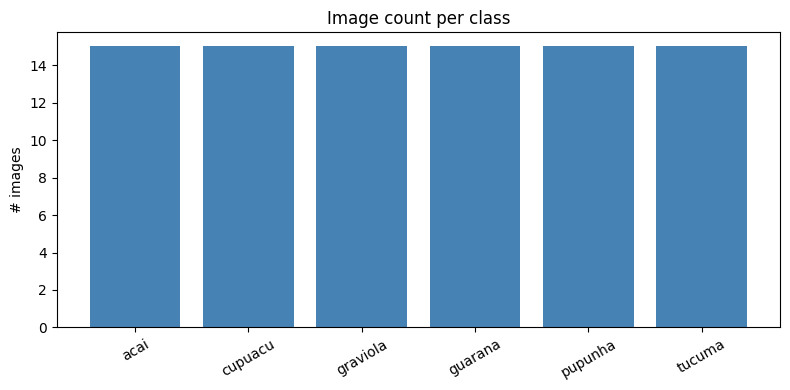

In [6]:
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)

plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title("Image count per class")
plt.ylabel("# images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 2.1.4 Visualise One Random Image per Class

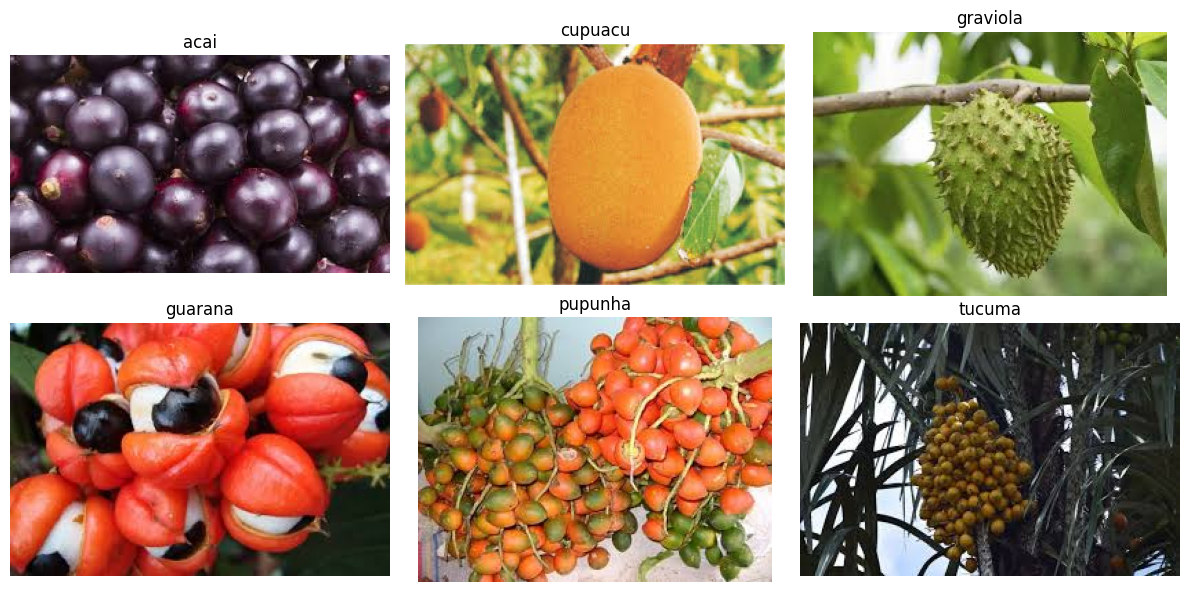

In [7]:
selected_images, selected_labels = [], []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_images.append(os.path.join(class_path, random.choice(images)))
            selected_labels.append(class_name)

num_classes_plot = len(selected_images)
cols = (num_classes_plot + 1) // 2
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes_plot:
        ax.imshow(mpimg.imread(selected_images[i]))
        ax.set_title(selected_labels[i])
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 2.2 Data Generation and Pre‑processing

In [8]:
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VAL_SPLIT,
    subset="both",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("\nClass names found by Keras:", class_names)

for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.

Class names found by Keras: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Images shape: (32, 224, 224, 3)
Labels shape: (32,)


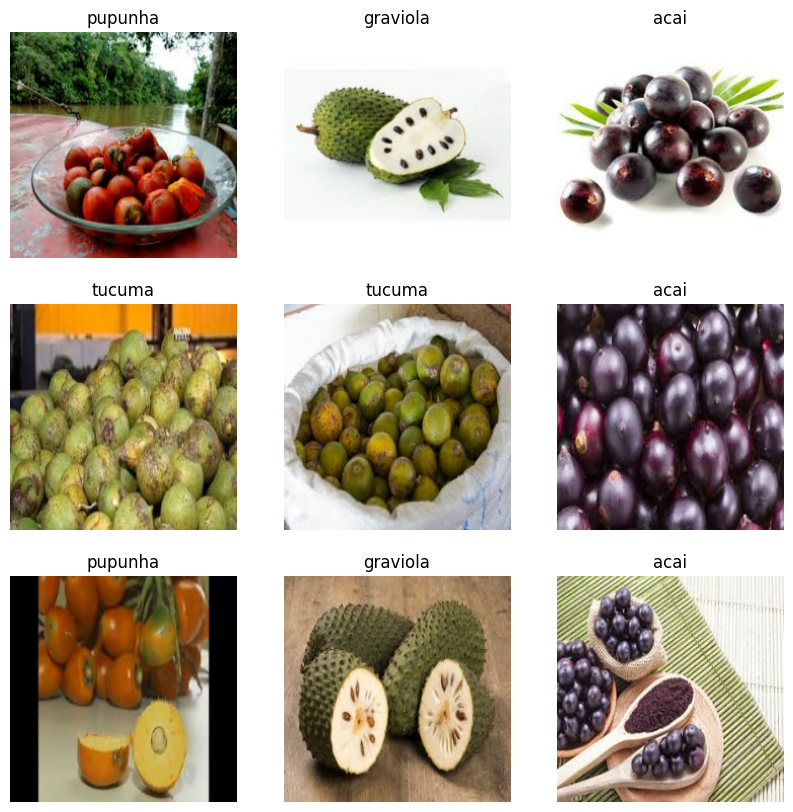

In [9]:
# Visualise a single training batch
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.show()

### 2.2.1 Data Augmentation (new `tf.keras.layers.Random*` API)

Runs on the GPU, automatically disabled at inference.

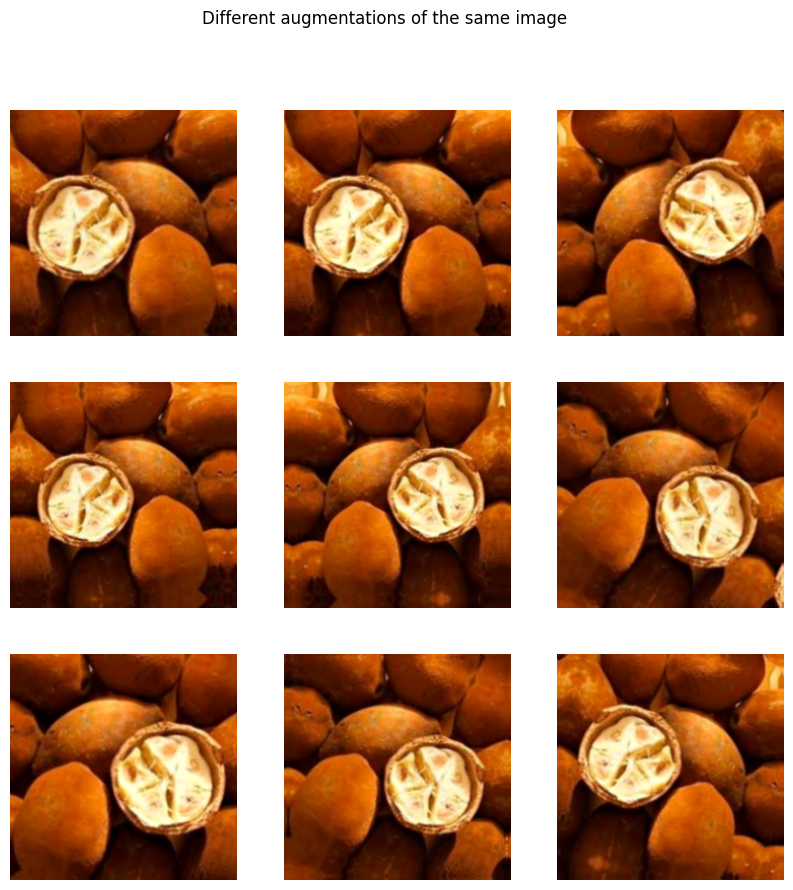

In [10]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# Visualise augmentations on one image
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented[0]).astype("uint8"))
        plt.axis("off")
plt.suptitle("Different augmentations of the same image")
plt.show()

In [ ]:
# Performance: prefetch to overlap CPU/GPU work
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

---
# 3. Task 1 — End‑to‑End CNN with BatchNormalization & Dropout

In [11]:
input_shape = IMG_SIZE + (3,)

def build_scratch_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    # Conv block 1
    x = Conv2D(32, (3, 3), padding='same')(x)
    x = BatchNormalization()(x); x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x); x = Dropout(0.25)(x)

    # Conv block 2
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = BatchNormalization()(x); x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x); x = Dropout(0.25)(x)

    # Conv block 3
    x = Conv2D(128, (3, 3), padding='same')(x)
    x = BatchNormalization()(x); x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x); x = Dropout(0.25)(x)

    # Conv block 4
    x = Conv2D(256, (3, 3), padding='same')(x)
    x = BatchNormalization()(x); x = Activation('relu')(x)
    x = MaxPooling2D((2, 2))(x); x = Dropout(0.25)(x)

    x = Flatten()(x)
    x = Dense(512)(x);  x = BatchNormalization()(x); x = Activation('relu')(x); x = Dropout(0.5)(x)
    x = Dense(256)(x);  x = BatchNormalization()(x); x = Activation('relu')(x); x = Dropout(0.5)(x)
    x = Dense(128)(x);  x = BatchNormalization()(x); x = Activation('relu')(x); x = Dropout(0.5)(x)
    x = Dense(64)(x);   x = BatchNormalization()(x); x = Activation('relu')(x); x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name="scratch_cnn")

scratch_model = build_scratch_cnn(input_shape, num_classes)
scratch_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
scratch_model.summary()

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,257,670 (100.17 MB)

 Trainable params: 26,254,790 (100.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

### 3.1 Train the scratch CNN

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=3, verbose=1),
]

history_scratch = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_SCRATCH,
    callbacks=callbacks,
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 6s/step - accuracy: 0.1389 - loss: 2.4311 - val_accuracy: 0.1667 - val_loss: 1.7851 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 7s/step - accuracy: 0.1944 - loss: 2.4284 - val_accuracy: 0.1111 - val_loss: 1.8104 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 6s/step - accuracy: 0.2083 - loss: 2.1213 - val_accuracy: 0.2778 - val_loss: 1.8033 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2159 - loss: 2.1480
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.1944 - loss: 2.1994 - val_accuracy: 0.2222 - val_loss: 1.8049 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.2222 - loss: 1.9809 - val_accuracy: 0.2222 - val_loss: 1.7974 - learning_rate: 5.0000e-04
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.1667 - loss: 2.3508 - val_accuracy: 0.1667 - val

### 3.2 Plot training curves

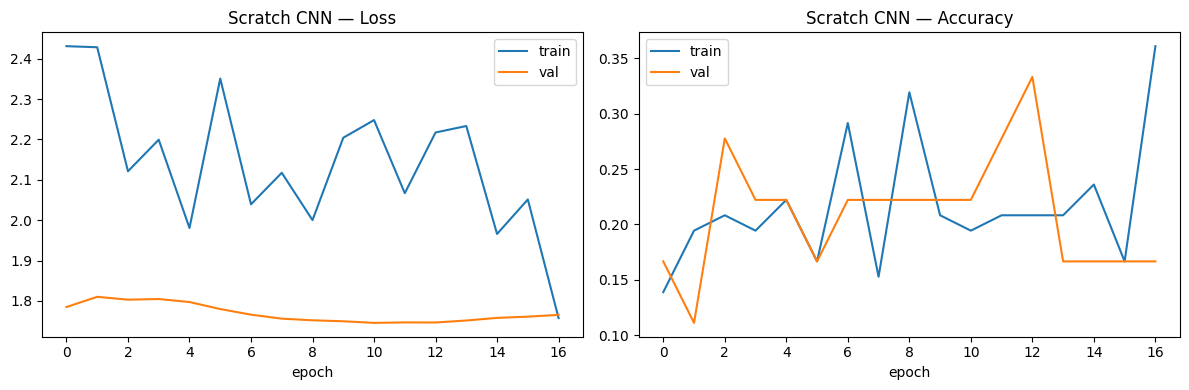

In [13]:
def plot_history(history, title):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h['loss'],     label='train')
    axes[0].plot(h['val_loss'], label='val')
    axes[0].set_title(f"{title} — Loss");      axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(h['accuracy'],     label='train')
    axes[1].plot(h['val_accuracy'], label='val')
    axes[1].set_title(f"{title} — Accuracy");  axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_history(history_scratch, "Scratch CNN")

### 3.3 Evaluate, classification report and confusion matrix

Scratch CNN — validation loss: 1.7458, accuracy: 0.2222

Classification report — Scratch CNN

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.22      1.00      0.36         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.22        18
   macro avg       0.04      0.17      0.06        18
weighted avg       0.05      0.22      0.08        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


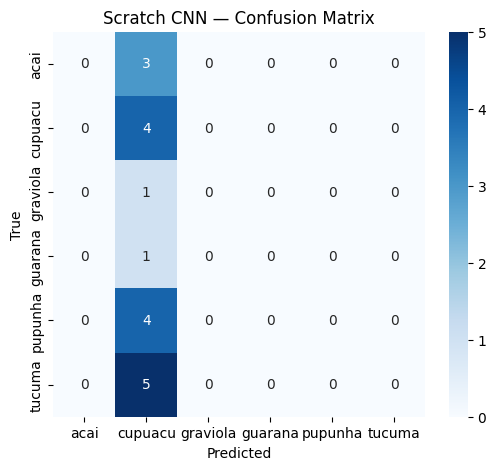

In [14]:
val_loss, val_acc = scratch_model.evaluate(val_ds, verbose=0)
print(f"Scratch CNN — validation loss: {val_loss:.4f}, accuracy: {val_acc:.4f}")

def predict_dataset(model, ds):
    y_true, y_pred = [], []
    for images, labels in ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

y_true_s, y_pred_s = predict_dataset(scratch_model, val_ds)

print("\nClassification report — Scratch CNN\n")
print(classification_report(y_true_s, y_pred_s, target_names=class_names))

cm_s = confusion_matrix(y_true_s, y_pred_s)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Scratch CNN — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

### 3.4 Make predictions on a few validation images

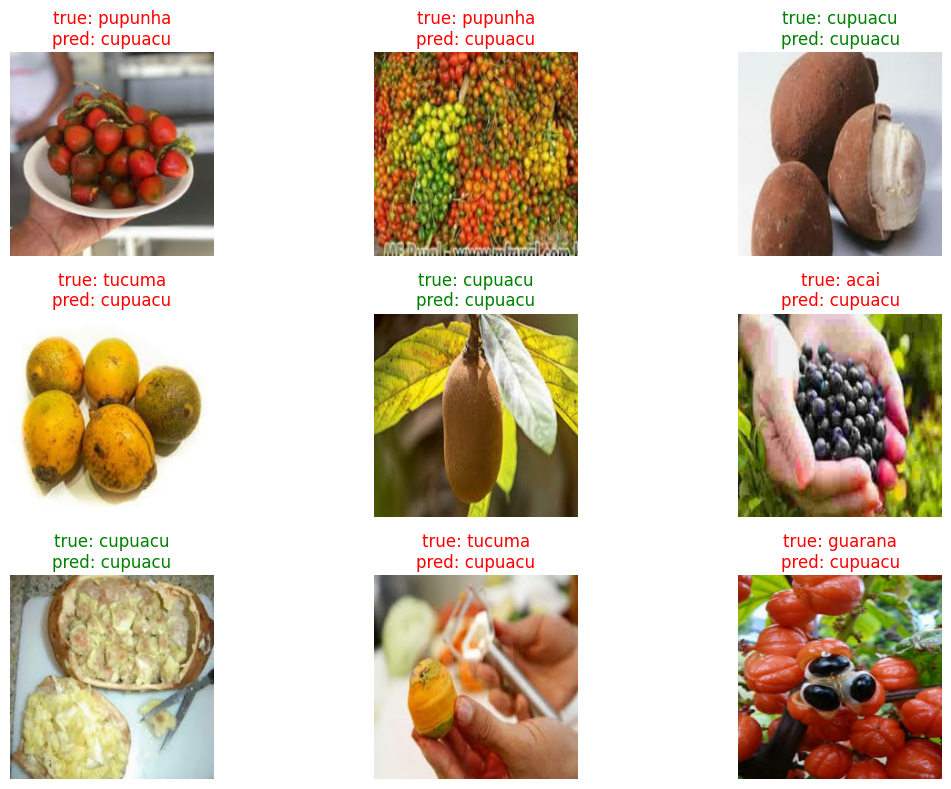

In [15]:
for images, labels in val_ds.take(1):
    preds = scratch_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    plt.figure(figsize=(12, 8))
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype('uint8'))
        true_lbl = class_names[int(labels[i])]
        pred_lbl = class_names[int(pred_labels[i])]
        col = 'green' if true_lbl == pred_lbl else 'red'
        plt.title(f"true: {true_lbl}\npred: {pred_lbl}", color=col)
        plt.axis('off')
    plt.tight_layout(); plt.show()

In [16]:
scratch_model.save("scratch_cnn_fruits.keras")
print("Saved: scratch_cnn_fruits.keras")

Saved: scratch_cnn_fruits.keras


---
# 4. Task 2 — Transfer Learning with VGG16

In [17]:
# 1. Load the pre‑trained VGG16 base (no top, ImageNet weights)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

# 2. Freeze all layers of the base model
for layer in base_model.layers:
    layer.trainable = False

print(f"Base model has {len(base_model.layers)} layers, all frozen.")
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model has 19 layers, all frozen.


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [18]:
# 3. Build the full model: augmentation -> preprocess -> VGG16 -> custom head
inputs = keras.Input(shape=input_shape)
x = data_augmentation(inputs)                                 # GPU augmentation
x = Lambda(preprocess_input, name="vgg16_preprocess")(x)      # VGG16‑specific preprocessing
x = base_model(x, training=False)                             # frozen feature extractor
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

vgg_model = Model(inputs, outputs, name="vgg16_transfer")
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
vgg_model.summary()

Model: "vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16_preprocess (Lambda)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### 4.1 Train (only the head learns)

In [19]:
history_vgg = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER,
    callbacks=callbacks,
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 23s/step - accuracy: 0.1111 - loss: 7.3548 - val_accuracy: 0.0556 - val_loss: 5.2279 - learning_rate: 1.0000e-04
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 17s/step - accuracy: 0.1389 - loss: 6.0622 - val_accuracy: 0.1667 - val_loss: 4.5973 - learning_rate: 1.0000e-04
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2998 - loss: 4.1700 
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
3/3 ━━━━━━━━━━━━━━━━━━━━ 92s 22s/step - accuracy: 0.3056 - loss: 4.5702 - val_accuracy: 0.2222 - val_loss: 4.3224 - learning_rate: 1.0000e-04
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 22s/step - accuracy: 0.4028 - loss: 3.2233 - val_accuracy: 0.2778 - val_loss: 4.0551 - learning_rate: 5.0000e-05
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 22s/step - accuracy: 0.4167 - loss: 3.5331 - val_accuracy: 0.2778 - val_loss: 3.8198 - learning_rate: 5.0000e-05
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.3345 - loss: 3.1929 
Epoc

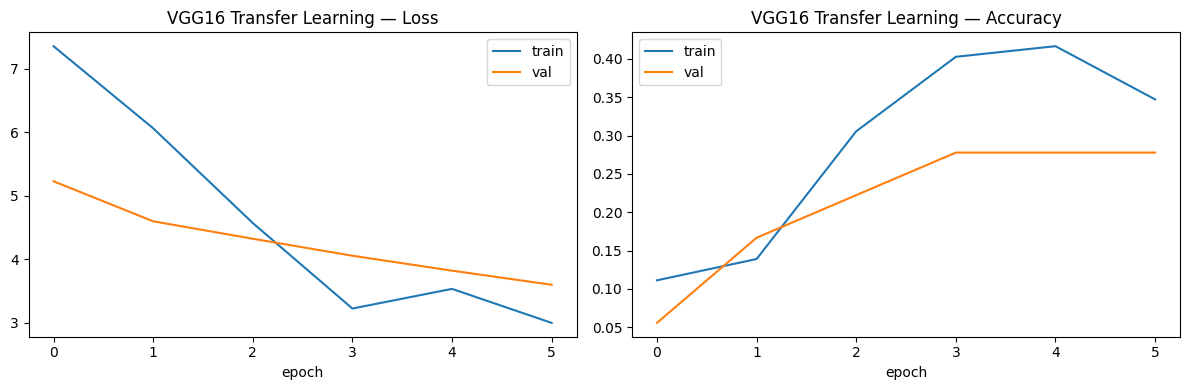

In [21]:
plot_history(history_vgg, "VGG16 Transfer Learning")

### 4.2 Evaluate, classification report and confusion matrix

VGG16 transfer — validation loss: 5.2279, accuracy: 0.0556

Classification report — VGG16 transfer

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         3
     cupuacu       0.25      0.25      0.25         4
    graviola       0.00      0.00      0.00         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.06        18
   macro avg       0.04      0.04      0.04        18
weighted avg       0.06      0.06      0.06        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


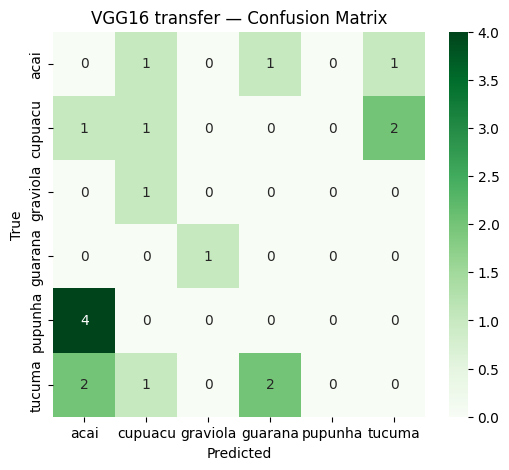

In [22]:
val_loss_v, val_acc_v = vgg_model.evaluate(val_ds, verbose=0)
print(f"VGG16 transfer — validation loss: {val_loss_v:.4f}, accuracy: {val_acc_v:.4f}")

y_true_v, y_pred_v = predict_dataset(vgg_model, val_ds)

print("\nClassification report — VGG16 transfer\n")
print(classification_report(y_true_v, y_pred_v, target_names=class_names))

cm_v = confusion_matrix(y_true_v, y_pred_v)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_v, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title("VGG16 transfer — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

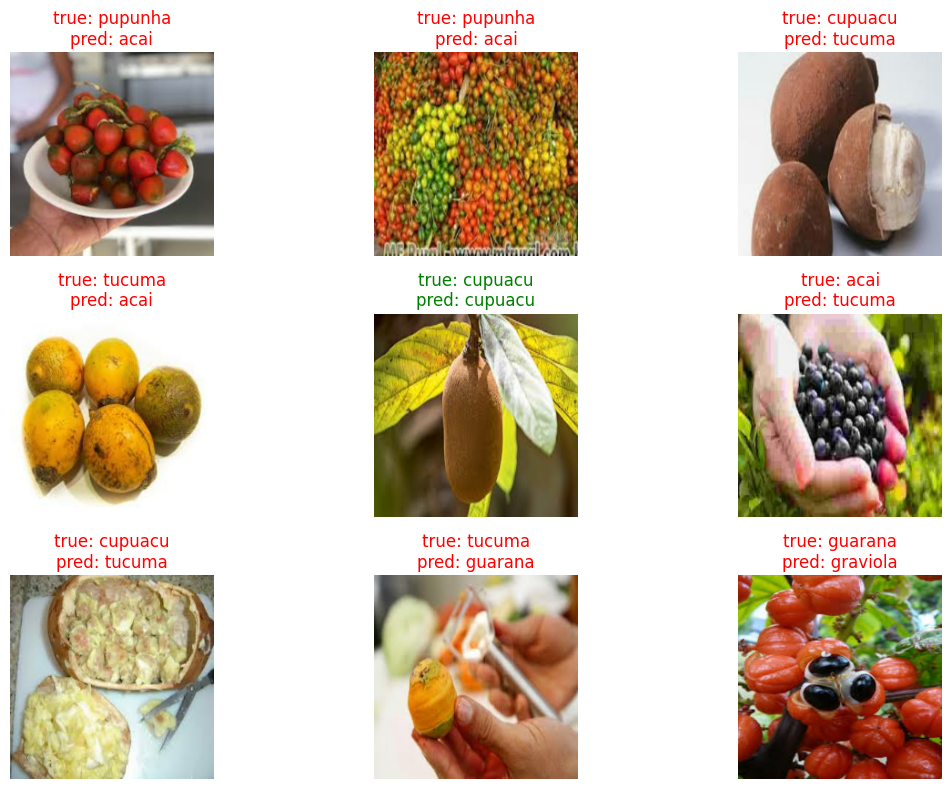

In [23]:
for images, labels in val_ds.take(1):
    preds = vgg_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    plt.figure(figsize=(12, 8))
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype('uint8'))
        true_lbl = class_names[int(labels[i])]
        pred_lbl = class_names[int(pred_labels[i])]
        col = 'green' if true_lbl == pred_lbl else 'red'
        plt.title(f"true: {true_lbl}\npred: {pred_lbl}", color=col)
        plt.axis('off')
    plt.tight_layout(); plt.show()

In [24]:
vgg_model.save("vgg16_transfer_fruits.keras")
print("Saved: vgg16_transfer_fruits.keras")

Saved: vgg16_transfer_fruits.keras


---
## 5. Comparison: scratch CNN vs. VGG16 transfer learning

Model                        Val loss     Val acc
-------------------------------------------------
Scratch CNN                    1.7458      0.2222
VGG16 transfer                 5.2279      0.0556


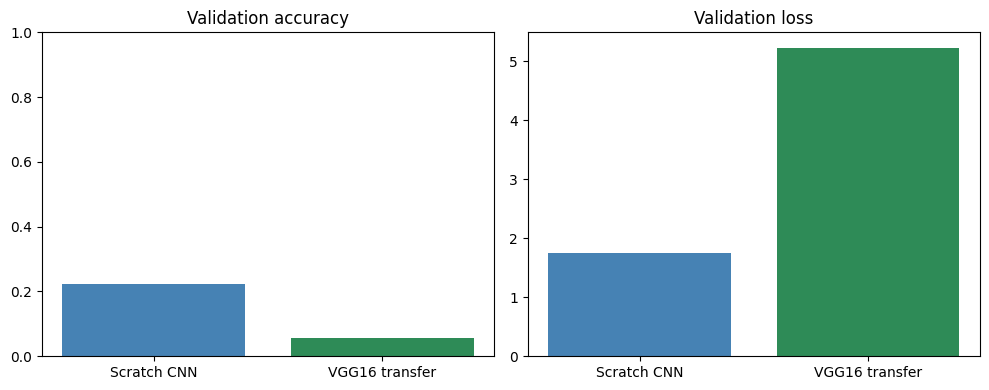

In [25]:
print(f"{'Model':<25}{'Val loss':>12}{'Val acc':>12}")
print("-" * 49)
print(f"{'Scratch CNN':<25}{val_loss:>12.4f}{val_acc:>12.4f}")
print(f"{'VGG16 transfer':<25}{val_loss_v:>12.4f}{val_acc_v:>12.4f}")

labels_cmp = ['Scratch CNN', 'VGG16 transfer']
accs   = [val_acc,  val_acc_v]
losses = [val_loss, val_loss_v]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels_cmp, accs,   color=['steelblue', 'seagreen']); axes[0].set_title("Validation accuracy"); axes[0].set_ylim(0, 1)
axes[1].bar(labels_cmp, losses, color=['steelblue', 'seagreen']); axes[1].set_title("Validation loss")
plt.tight_layout(); plt.show()